In [1]:
from datasets import load_dataset

ds = load_dataset("giswqs/EuroSAT_MS")

/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(ds.keys())
ds_train = ds['train']
ds_test = ds['test']
ds_validation = ds['validation']

ds['train']



dict_keys(['train', 'validation', 'test'])


Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 18880
})

In [3]:
print("Train : ", len(ds_train), len(ds_train['image'][0]), len(ds_train['image'][0][0]), len(ds_train['image'][0][0][0]))
print("Test : ", len(ds_test), len(ds_test['image'][0]), len(ds_test['image'][0][0]), len(ds_test['image'][0][0][0]))
print("Validation : ", len(ds_validation), len(ds_validation['image'][0]), len(ds_validation['image'][0][0]), len(ds_validation['image'][0][0][0]))

Train :  18880 13 64 64
Test :  2713 13 64 64
Validation :  5405 13 64 64


In [4]:
for i in range(0, len(ds_train), 500):
    # i = i %  500     
    print("Train : ", len(ds_train['image'][i]), len(ds_train['image'][i][0]), len(ds_train['image'][i][0][0]), ds_train['filename'][i])


Train :  13 64 64 PermanentCrop/PermanentCrop_2401.tif
Train :  13 64 64 AnnualCrop/AnnualCrop_2472.tif
Train :  13 64 64 AnnualCrop/AnnualCrop_374.tif
Train :  13 64 64 Forest/Forest_1884.tif
Train :  13 64 64 SeaLake/SeaLake_1074.tif
Train :  13 64 64 Pasture/Pasture_900.tif
Train :  13 64 64 Pasture/Pasture_1650.tif
Train :  13 64 64 Pasture/Pasture_1267.tif
Train :  13 64 64 PermanentCrop/PermanentCrop_638.tif
Train :  13 64 64 AnnualCrop/AnnualCrop_1403.tif
Train :  13 64 64 SeaLake/SeaLake_2206.tif
Train :  13 64 64 Industrial/Industrial_1264.tif
Train :  13 64 64 River/River_1795.tif
Train :  13 64 64 River/River_2422.tif
Train :  13 64 64 Pasture/Pasture_1443.tif
Train :  13 64 64 Residential/Residential_2449.tif
Train :  13 64 64 HerbaceousVegetation/HerbaceousVegetation_1244.tif
Train :  13 64 64 SeaLake/SeaLake_2727.tif
Train :  13 64 64 River/River_209.tif
Train :  13 64 64 River/River_655.tif
Train :  13 64 64 Industrial/Industrial_2208.tif
Train :  13 64 64 Industrial/Ind

In [5]:
import numpy as np 

img_1_sample = np.array(ds_train['image'][0])
rgb = np.stack([img_1_sample[3], img_1_sample[2], img_1_sample[1]], axis=-1)

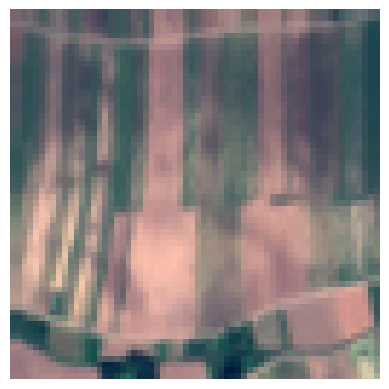

In [6]:
import cv2 

import matplotlib.pyplot as plt

rgb = rgb.astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.axis("off");

In [7]:
for i in range(13):

    print(f"Channel- {i+1}  Min and Max : ", np.min(img_1_sample[i]), np.max(img_1_sample[i]))

# converting abs val to reflectance ( /10000)

def to_reflectance(example):
    # example = ONE row/sample
    example["image"] = np.array(example["image"], dtype=np.float32) / 10000
    return example



ds_train = ds_train.map(to_reflectance)

for i in range(13):

    print(f"Channel- {i+1}  Min and Max : ", np.min(img_1_sample[i]), np.max(img_1_sample[i]))

Channel- 1  Min and Max :  1308 1630
Channel- 2  Min and Max :  829 1656
Channel- 3  Min and Max :  598 1824
Channel- 4  Min and Max :  419 2194
Channel- 5  Min and Max :  761 2302
Channel- 6  Min and Max :  1423 3198
Channel- 7  Min and Max :  1630 3738
Channel- 8  Min and Max :  1140 4590
Channel- 9  Min and Max :  668 949
Channel- 10  Min and Max :  9 15
Channel- 11  Min and Max :  1375 3674
Channel- 12  Min and Max :  683 2945
Channel- 13  Min and Max :  1868 4064
Channel- 1  Min and Max :  1308 1630
Channel- 2  Min and Max :  829 1656
Channel- 3  Min and Max :  598 1824
Channel- 4  Min and Max :  419 2194
Channel- 5  Min and Max :  761 2302
Channel- 6  Min and Max :  1423 3198
Channel- 7  Min and Max :  1630 3738
Channel- 8  Min and Max :  1140 4590
Channel- 9  Min and Max :  668 949
Channel- 10  Min and Max :  9 15
Channel- 11  Min and Max :  1375 3674
Channel- 12  Min and Max :  683 2945
Channel- 13  Min and Max :  1868 4064


In [ ]:
sum_ = np.zeros(13, dtype=np.float64)
sum_sq = np.zeros(13, dtype=np.float64)
count = 0

for example in ds_train:

    img = np.array(example["image"], dtype=np.float32)

    # img = (13, 64, 64)

    sum_ += img.reshape(13, -1).sum(axis=1)
    sum_sq += (img.reshape(13, -1) ** 2).sum(axis=1)

    count += img.shape[1] * img.shape[2]

mean = sum_ / count
std = np.sqrt(sum_sq / count - mean ** 2)

print("Mean:", mean)
print("Std :", std)

'''
output : 
Mean: [0.13543268 0.11175188 0.10418837 0.09467538 0.11996479 0.20028183
 0.23731175 0.23004931 0.07332496 0.0012104  0.18213873 0.11190669
 0.25987505]
Std : [0.02457886 0.03333259 0.0395221  0.05942802 0.05672322 0.08590868
 0.10834781 0.11147044 0.04039885 0.00047205 0.10015353 0.07607304
 0.12276264]
'''

Mean: [0.13543268 0.11175188 0.10418837 0.09467538 0.11996479 0.20028183
 0.23731175 0.23004931 0.07332496 0.0012104  0.18213873 0.11190669
 0.25987505]
Std : [0.02457886 0.03333259 0.0395221  0.05942802 0.05672322 0.08590868
 0.10834781 0.11147044 0.04039885 0.00047205 0.10015353 0.07607304
 0.12276264]


In [9]:
def normalize(example):

    img = np.array(example["image"], dtype=np.float32)

    img = (img - mean[:, None, None]) / std[:, None, None]

    example["image"] = img

    return example


ds_train = ds_train.map(normalize)

Map: 100%|██████████| 18880/18880 [04:54<00:00, 64.12 examples/s]


In [14]:
for i in range(13):

    print(f"Img channel - {i} | max : {np.max(ds_train['image'][i]):.3f} min : {np.min(ds_train['image'][i]):.3f}")

Img channel - 0 | max : 2.400 min : -1.123
Img channel - 1 | max : 4.684 min : -0.055
Img channel - 2 | max : 1.037 min : -1.366
Img channel - 3 | max : -0.530 min : -2.003
Img channel - 4 | max : 1.463 min : -2.043
Img channel - 5 | max : 1.963 min : -1.081
Img channel - 6 | max : 1.450 min : -0.337
Img channel - 7 | max : 0.958 min : -0.921
Img channel - 8 | max : 3.203 min : -1.164
Img channel - 9 | max : 1.557 min : -1.577
Img channel - 10 | max : 2.954 min : -0.794
Img channel - 11 | max : 2.224 min : -1.232
Img channel - 12 | max : 1.913 min : -0.909


In [15]:
ds_train.save_to_disk("EuroSAT_MS_train")

Saving the dataset (9/9 shards): 100%|██████████| 18880/18880 [00:01<00:00, 11553.06 examples/s]


In [16]:
len(ds_train['image'])

18880